# Explore official gaming revenue
Start here. Change the variables below, then **Restart Kernel and Run All**.
This notebook reads local SQLite data. It does not download, migrate, or write to the database.
CSV export at the end is optional and disabled by default.

In [1]:
database_file = "data/staging/gaming_nationwide.sqlite"  # or "data/gaming.sqlite"
states = None  # None = every state present in gaming_results; or e.g. ["MA", "NJ"]
product = "online_sports_betting"  # or "online_casino"
metric = "gross_revenue"  # adjusted_revenue, taxable_revenue, net_proceeds, handle, tax
start_date = "2025-01-01"
end_date = None  # None means the latest stored period
frequency = "monthly"  # or "weekly"; weeks are never turned into months
channel = "online"
growth_states_reviewed = []  # [] skips until reviewed; or e.g. ["MA", "NJ"] after reading reports

## 1. Read local data
One database holds the observations and their source references. Each file hash is retained.
Equal copies collapse for analysis. If reports disagree, their values stay unselected until reviewed.

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from variant_gaming.consolidate import MONEY_COLUMNS, build_state_period_revenue, build_source_coverage_export
from variant_gaming.storage import connect_readonly

database_path = ROOT / database_file
print(f"Reading: {database_path}")
connection = connect_readonly(database_path)
try:
    results = pd.read_sql_query("SELECT * FROM gaming_results", connection)
    coverage = build_source_coverage_export(connection, ROOT)
finally:
    connection.close()
inventory = pd.read_csv(ROOT / "config/state_gaming_source_inventory.csv").fillna("")
metric_notes = pd.read_csv(ROOT / "config/state_metric_notes.csv").fillna("unknown")

Reading: C:\Users\Sean\VscProjects\researchOS\data\staging\gaming_nationwide.sqlite


In [4]:
if states is None:
    states = sorted(results["state_code"].dropna().astype(str).str.upper().unique())
else:
    states = list(dict.fromkeys(state.upper() for state in states))
    unknown = set(states) - set(coverage["state_code"])
    if not states or unknown:
        raise ValueError(f"Choose inventory states; unknown={sorted(unknown)}")
growth_states_reviewed = (
    [] if growth_states_reviewed is None
    else list(dict.fromkeys(state.upper() for state in growth_states_reviewed))
)
if metric not in MONEY_COLUMNS:
    raise ValueError(f"Choose a metric from {MONEY_COLUMNS}")
if product not in {"online_sports_betting", "online_casino"}:
    raise ValueError("Choose online_sports_betting or online_casino")
if frequency not in {"monthly", "weekly"}:
    raise ValueError("Choose monthly or weekly")
start = pd.Timestamp(start_date)
end = pd.Timestamp(end_date) if end_date else pd.Timestamp(results["period_end"].max())
if start > end:
    raise ValueError("start_date must be on or before end_date")

## 2. Read the definitions before comparing
The inventory is a dated source-research snapshot. Its counts/ranges refer to the staging database.
The stored coverage table below describes the database you selected. Neither proves complete history.

Read the notes for the **selected metric**, especially timing, promotions and other deductions.
An unknown definition date means the example has not been shown to apply to all historical periods.
Connecticut and Pennsylvania have corrected mappings in staging; the original database keeps its older values.

- State growth needs the same period, channel and financial definition, including deduction rules.
- Cross-state totals need compatible definitions and a disclosed list of included states. No national total is calculated here.
- Hold needs matching wager and revenue definitions. Illinois uses different timing bases; Pennsylvania casino wagers omit poker volume.
- Market share needs matching operator identities and a complete denominator. Licensees are not automatically brands.
- Revenue-only analysis can proceed without handle. Missing values and source conflicts remain visible.

In [5]:
source_notes = inventory[inventory.state_code.isin(states) & inventory.vertical.eq(product)]
display(source_notes[["state_code", "collection_status", "source_checked_at_utc", "channel_coverage", "status_note", "next_action"]])
definitions = metric_notes[metric_notes.state_code.isin(states) & metric_notes.vertical.eq(product)
                          & metric_notes.storage_column.isin([metric, "none"])]
display(definitions[["state_code", "source_label", "definition", "timing_basis", "promotions_and_deductions",
                     "reporting_frequency", "definition_applies_from", "definition_applies_to", "evidence_period", "source_url"]])

selected_coverage = coverage[
    coverage["state_code"].isin(states) & coverage["vertical"].eq(product)
]
display(selected_coverage[["state_code", "status", "earliest_period", "latest_period", "reason", "official_url"]])

selected = results[results["state_code"].isin(states) & results["vertical"].eq(product)].copy()
analysis_rows = selected.copy()
# The preserved database predates these mapping repairs. Keep its raw rows in the trace.
if database_path.resolve() == (ROOT / "data/gaming.sqlite").resolve():
    needs_replay = (["CT"] if metric == "gross_revenue" else
                    ["NJ"] if metric in {"tax", "taxable_revenue"} else [])
    analysis_rows.loc[analysis_rows.state_code.isin(needs_replay), metric] = float("nan")
    if set(needs_replay) & set(states):
        print("Use staging for the corrected CT gross or NJ tax fields; original values are excluded.")
period_rows = build_state_period_revenue(analysis_rows, metric=metric)
period_rows["period_start"] = pd.to_datetime(period_rows["period_start"])
period_rows["period_end"] = pd.to_datetime(period_rows["period_end"])
in_window = period_rows["period_start"].ge(start) & period_rows["period_end"].le(end)
requested = period_rows[in_window & period_rows["frequency"].eq(frequency) & period_rows["channel"].eq(channel)].copy()

,state_code,collection_status,source_checked_at_utc,channel_coverage,status_note,next_action
10,CO,partially_collected,2026-09-05,online,Archive is July 2021-February 2026 with July 2...,"Use notebook 90 to check the requested metric,..."
12,CT,collected_and_validated,2026-09-05,online,Staging corrects the legacy mapping: printed o...,"Use notebook 90 to check the requested metric,..."
14,DC,partially_collected,2026-09-05,online,Stored official history starts July 2024; earl...,"Use notebook 90 to check the requested metric,..."
16,DE,combined_reporting_only,2026-09-05,mobile and retail combined,Official lottery sportsbook tables group casin...,Obtain separately labeled online activity and ...
24,IA,collected_and_validated,2026-09-05,online,Retained official reports parsed with state-sp...,"Use notebook 90 to check the requested metric,..."
28,IL,collected_and_validated,2026-09-05,online,Handle uses all wagering activity while State ...,"Use notebook 90 to check the requested metric,..."
30,IN,collected_and_validated,2026-09-05,online,Legacy calculated totals remain classified as ...,"Use notebook 90 to check the requested metric,..."
32,KS,partially_collected,2026-09-05,online,Current detail archive starts January 2023; Se...,"Use notebook 90 to check the requested metric,..."
34,KY,partially_collected,2026-09-05,online,Only March-April 2025 statewide online figures...,"Use notebook 90 to check the requested metric,..."
36,LA,partially_collected,2026-09-05,online,FY22 workbook final two rows print July/August...,"Use notebook 90 to check the requested metric,..."


,state_code,source_label,definition,timing_basis,promotions_and_deductions,reporting_frequency,definition_applies_from,definition_applies_to,evidence_period,source_url
11,CO,Total GGR - Online,Printed online gross wagers less payments to p...,unknown,NSBP includes allowed deductions; promotion al...,monthly,unknown,unknown,2024-06-01 to 2024-06-30,https://spl.cde.state.co.us/artemis/revserials...
16,CT,Online Sports Wagering Win/(Loss) / Online Cas...,Printed online win/loss before federal excise ...,unknown,Gross and taxable/payment calculations differ....,monthly,unknown,unknown,2026-07-01 to 2026-07-31,https://data.ct.gov/api/views/xf6g-659c/rows.c...
25,DC,Gross Gaming Revenue (GGR),Native reported gaming win/receipts in this so...,unknown,unknown; inspect the linked report and applica...,monthly,unknown,unknown,2026-07-01 to 2026-07-31,https://dclottery.com/olg/financials/july-2026...
28,DE,no collected metric,Official lottery sportsbook tables group casin...,unknown,unknown,accounting periods,unknown,unknown,none,https://delottery.com/Sports-Lottery/Monthly-N...
47,IN,Gross Receipts,Native reported gaming win/receipts in this so...,unknown,unknown; inspect the linked report and applica...,monthly,unknown,unknown,2026-07-01 to 2026-07-31,https://www.in.gov/igc/files/reports/2026/2026...
64,MA,Accrual Win,"Accrual Win from settled sports wagers, retain...",accrual,Taxable revenue has promotional/other adjustme...,monthly,unknown,unknown,2026-07-01 to 2026-07-31,https://massgaming.com/wp-content/uploads/MGC-...
77,MI,Gross Receipts,Native reported gaming win/receipts in this so...,unknown,Adjusted Gross includes product-specific permi...,monthly,unknown,unknown,2026-07-01 to 2026-07-31,https://www.michigan.gov/mgcb/-/media/Project/...
94,NC,Gross Wagering Revenue,Native reported gaming win/receipts in this so...,unknown,unknown; inspect the linked report and applica...,monthly,unknown,unknown,2026-07-01 to 2026-07-31,https://ncgaming.gov/wp-content/uploads/2026/0...
102,NH,Mobile GGR,Native reported gaming win/receipts in this so...,unknown,unknown; inspect the linked report and applica...,monthly,unknown,unknown,2026-07-01 to 2026-07-31,https://assets.ctfassets.net/1h4s33nxm7rw/M2se...
105,NJ,Monthly Internet Sports Wagering Gross Revenue...,Native reported gaming win/receipts in this so...,unknown,unknown; inspect the linked report and applica...,monthly,unknown,unknown,2026-07-01 to 2026-07-31,https://www.nj.gov/oag/ge/docs/Financials/SWRT...


,state_code,status,earliest_period,latest_period,reason,official_url
10,CO,ok,2021-07-01,2026-02-28,55 parsed reports; 0 failures. Details: C:\Use...,https://spl.cde.state.co.us/artemis/revserials...
12,CT,collected_and_validated,2021-10-01,2026-07-31,Staging corrects the legacy mapping: printed o...,https://portal.ct.gov/dcp/gaming-division/gami...
14,DC,partially_collected,2024-07-01,2026-07-31,Stored official history starts July 2024; earl...,https://dclottery.com/olg/financials
16,DE,combined_reporting_only,NaN,NaN,Official lottery sportsbook tables group casin...,https://delottery.com/Sports-Lottery/Monthly-N...
24,IA,collected_and_validated,2019-08-01,2026-07-31,Retained official reports parsed with state-sp...,https://irgc.iowa.gov/publications-reports/spo...
28,IL,collected_and_validated,2020-03-01,2026-06-30,Handle uses all wagering activity while State ...,https://igb.illinois.gov/sports-wagering/sport...
30,IN,collected_and_validated,2019-10-01,2026-07-31,Legacy calculated totals remain classified as ...,https://www.in.gov/igc/publications/monthly-re...
32,KS,partially_collected,2023-01-01,2026-07-31,Current detail archive starts January 2023; Se...,https://www.kslottery.gov/publications/sports-...
34,KY,partially_collected,2025-03-01,2025-04-30,Only March-April 2025 statewide online figures...,https://khrc.ky.gov/newstatic_info.aspx/utils/...
36,LA,partially_collected,2022-01-01,2026-07-31,FY22 workbook final two rows print July/August...,https://lgcb.dps.louisiana.gov/reports/


In [6]:
availability = []
for state in states:
    stored = selected[selected["state_code"].eq(state)]
    rows = requested[requested["state_code"].eq(state)]
    note = ""
    if stored.empty:
        note = "No stored observations for this product"
    elif rows.empty:
        note = "No online periods wholly inside the dates at this frequency"
    elif rows["revenue"].isna().all():
        note = "Selected metric is missing or has unresolved source conflicts"
    availability.append({"state": state, "stored_frequencies": ", ".join(sorted(stored["frequency"].unique())),
                         "periods_in_selection": len(rows), "periods_with_values": rows["revenue"].notna().sum(), "note": note})
display(pd.DataFrame(availability))

,state,stored_frequencies,periods_in_selection,periods_with_values,note
0,CO,monthly,13,0,Selected metric is missing or has unresolved s...
1,CT,monthly,19,19,
2,DC,monthly,19,18,
3,DE,,0,0,No stored observations for this product
4,IA,monthly,19,0,Selected metric is missing or has unresolved s...
5,IL,monthly,18,0,Selected metric is missing or has unresolved s...
6,IN,monthly,19,19,
7,KS,monthly,19,0,Selected metric is missing or has unresolved s...
8,KY,monthly,2,0,Selected metric is missing or has unresolved s...
9,LA,monthly,19,0,Selected metric is missing or has unresolved s...


## 3. Inspect the selected state-period rows
`reported_total` is a total printed in a regulator report.
`operator_coverage_unverified` is the sum of **observed operators**, whose market coverage has not been proven.
`missing_values` means at least one contributing row lacks the selected metric.
`conflicting_sources` means retained reports disagree. No winner is assumed.

Numbers from observed operators remain useful to inspect, but are not certified statewide totals.
The source's row label may describe another retained financial column; inspect the report for the selected metric's definition.

In [7]:
table = requested.sort_values(["state_code", "period_start"]).reset_index(drop=True)
columns = ["state_code", "period_start", "period_end", "frequency", metric,
           "aggregation_source", "completeness", "operator_count", "reported_revenue_name"]
display(table[list(dict.fromkeys(columns))])

excluded = table[table["revenue"].isna()]
print(f"{len(excluded)} selected periods have no usable value; see the reason below.")
display(excluded[["state_code", "period_start", "completeness", "source_file"]])

,state_code,period_start,period_end,frequency,gross_revenue,aggregation_source,completeness,operator_count,reported_revenue_name
0,CO,2025-01-01,2025-01-31,monthly,NaN,official_statewide_total,missing_values,0,Net Sports Betting Proceeds (NSBP)
1,CO,2025-02-01,2025-02-28,monthly,NaN,official_statewide_total,missing_values,0,Net Sports Betting Proceeds (NSBP)
2,CO,2025-03-01,2025-03-31,monthly,NaN,official_statewide_total,missing_values,0,Net Sports Betting Proceeds (NSBP)
3,CO,2025-04-01,2025-04-30,monthly,NaN,official_statewide_total,missing_values,0,Net Sports Betting Proceeds (NSBP)
4,CO,2025-05-01,2025-05-31,monthly,NaN,official_statewide_total,missing_values,0,Net Sports Betting Proceeds (NSBP)
...,...,...,...,...,...,...,...,...,...
429,WY,2026-03-01,2026-03-31,monthly,1944149.68,official_statewide_total,reported_total,5,Gross Gaming Revenue
430,WY,2026-04-01,2026-04-30,monthly,1852078.23,official_statewide_total,reported_total,5,Gross Gaming Revenue
431,WY,2026-05-01,2026-05-31,monthly,1977424.41,official_statewide_total,reported_total,5,Gross Gaming Revenue
432,WY,2026-06-01,2026-06-30,monthly,1409388.03,official_statewide_total,reported_total,5,Gross Gaming Revenue


175 selected periods have no usable value; see the reason below.


,state_code,period_start,completeness,source_file
0,CO,2025-01-01,missing_values,data\raw\CO\2026-09-05\2a43b1ce4a8ac6721c892ea...
1,CO,2025-02-01,missing_values,data\raw\CO\2026-09-05\97db774bfc0d227f0545638...
2,CO,2025-03-01,missing_values,data\raw\CO\2026-09-05\103b8f1f51172dc5656656a...
3,CO,2025-04-01,missing_values,data\raw\CO\2026-09-05\f124a2f5b483e9dbc3df837...
4,CO,2025-05-01,missing_values,data\raw\CO\2026-09-05\6bbbb796c35cd6e84cf73d7...
...,...,...,...,...
410,VT,2026-03-01,missing_values,data\raw\VT\2026-09-05\66aca0d01db6c827300d296...
411,VT,2026-04-01,missing_values,data\raw\VT\2026-09-05\a6ebb7541c21f1ed2b43a41...
412,VT,2026-05-01,missing_values,data\raw\VT\2026-09-05\cb578b5841c854046e22c71...
413,VT,2026-06-01,missing_values,data\raw\VT\2026-09-05\548a8daa3294637e6e336b0...


In [8]:
# Missing months appear as gaps, not zeros. Weekly dates remain as reported.
missing_months = []
if frequency == "monthly":
    expected = pd.date_range(start, end, freq="MS")
    expected = expected[expected + pd.offsets.MonthEnd(0) <= end]
    for state in states:
        present = table.loc[table["state_code"].eq(state), "period_start"]
        for month in expected.difference(present):
            missing_months.append({"state": state, "missing_month": month.date()})
print("Absent monthly rows (may include pre-launch months or unavailable history):")
display(pd.DataFrame(missing_months, columns=["state", "missing_month"]))

Absent monthly rows (may include pre-launch months or unavailable history):


,state,missing_month
0,CO,2025-07-01
1,CO,2026-03-01
2,CO,2026-04-01
3,CO,2026-05-01
4,CO,2026-06-01
...,...,...
93,WV,2026-03-01
94,WV,2026-04-01
95,WV,2026-05-01
96,WV,2026-06-01


## 4. View the trend
Solid lines show published statewide totals. Dashed lines show observed-operator sums with unverified coverage.
Missing values are gaps. No missing month is estimated.

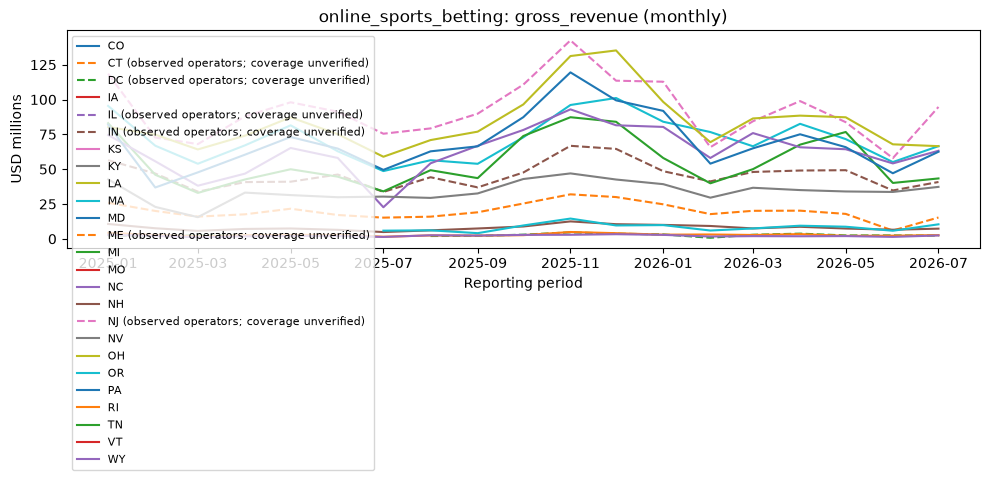

In [9]:
if table["revenue"].notna().any():
    fig, ax = plt.subplots(figsize=(10, 4))
    for (state, scope), group in table.groupby(["state_code", "aggregation_source"]):
        series = group.set_index("period_start")["revenue"].sort_index()
        if frequency == "monthly":
            series = series.reindex(pd.date_range(series.index.min(), series.index.max(), freq="MS"))
        official = scope == "official_statewide_total"
        label = state if official else f"{state} (observed operators; coverage unverified)"
        ax.plot(series.index, series / 1e6, label=label, linestyle="-" if official else "--")
    ax.set(title=f"{product}: {metric} ({frequency})", ylabel="USD millions", xlabel="Reporting period")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print("No values to chart for this selection. Review coverage or choose another metric.")

## 5. Year-over-year growth after definition review
Read the relevant reports and metric notes for the entire selected window. The table below lists states with mechanically eligible year-over-year pairs, labeled **pending analyst review**. Add reviewed states to `growth_states_reviewed` above only after you confirm the comparison is appropriate.

YoY estimates are calculated only for states explicitly listed in `growth_states_reviewed`. An empty list skips growth entirely.

The mechanical eligibility check requires published statewide monthly totals, matching labels, the same month a year earlier, both periods inside the selected window, and a positive prior value. Partial launch periods need review too.

In [10]:
def _yoy_pairs(official: pd.DataFrame) -> pd.DataFrame:
    columns = ["state_code", "period_start", "revenue", "prior_revenue", "yoy_pct"]
    if frequency != "monthly" or official.empty:
        return pd.DataFrame(columns=columns)
    prior = official[["state_code", "period_start", "revenue", "reported_revenue_name"]].copy()
    prior["period_start"] = prior["period_start"] + pd.DateOffset(years=1)
    prior = prior.rename(columns={"revenue": "prior_revenue"})
    matches = official.merge(
        prior, on=["state_code", "period_start", "reported_revenue_name"], validate="one_to_one"
    )
    matches = matches[matches["prior_revenue"].gt(0)]
    matches["yoy_pct"] = 100 * (matches["revenue"] / matches["prior_revenue"] - 1)
    return matches[columns]


official_candidates = table[
    table["completeness"].eq("reported_total") & table.state_code.isin(states)
].copy()
candidate_pairs = _yoy_pairs(official_candidates)
if candidate_pairs.empty:
    print("No mechanically eligible year-over-year pairs among selected states.")
else:
    pending = (
        candidate_pairs.groupby("state_code", as_index=False)
        .agg(pair_count=("period_start", "size"))
        .assign(review_status="pending analyst review")
        .sort_values("state_code")
    )
    display(pending)
    print(
        "Pending analyst review: mechanically eligible pairs only. "
        "No YoY estimate is calculated until a state is listed in growth_states_reviewed."
    )

if growth_states_reviewed:
    reviewed_official = official_candidates[official_candidates.state_code.isin(growth_states_reviewed)]
    yoy = _yoy_pairs(reviewed_official)
    display(yoy.groupby("state_code", as_index=False).tail(1))
    if yoy.empty:
        print("No qualifying year-over-year pairs for reviewed states. No comparison has been estimated.")
else:
    print("No states in growth_states_reviewed. No YoY comparison has been estimated.")

,state_code,pair_count,review_status
0,MA,7,pending analyst review
1,MI,7,pending analyst review
2,NC,7,pending analyst review
3,NH,7,pending analyst review
4,NV,7,pending analyst review
5,OH,7,pending analyst review
6,OR,1,pending analyst review
7,PA,7,pending analyst review
8,RI,7,pending analyst review
9,WY,7,pending analyst review


Pending analyst review: mechanically eligible pairs only. No YoY estimate is calculated until a state is listed in growth_states_reviewed.
No states in growth_states_reviewed. No YoY comparison has been estimated.


## 6. Trace a number to its source
Choose a state and period below. This displays the original operator and statewide observations,
including conflicting versions and legacy derived totals. It never sums these raw rows together.
Open `source_file` relative to the repository; Illinois references two files separated by `|`.

In [11]:
trace_state = states[0]
trace_period = None  # e.g. "2026-07-01"; None selects this state's latest displayed period
state_rows = table[table["state_code"].eq(trace_state)]
if trace_period is None and not state_rows.empty:
    trace_period = state_rows["period_start"].max().date().isoformat()
trace = selected[selected["state_code"].eq(trace_state) & selected["period_start"].eq(trace_period)]
trace_columns = ["operator", "row_type", metric, "report_status", "reported_revenue_name",
                 "source_url", "source_file", "source_sha256", "retrieved_at_utc"]
with pd.option_context("display.max_colwidth", None):
    display(trace[trace_columns])

,operator,row_type,gross_revenue,report_status,reported_revenue_name,source_url,source_file,source_sha256,retrieved_at_utc
17736,STATEWIDE,official_statewide_total,NaN,reported,Net Sports Betting Proceeds (NSBP),https://spl.cde.state.co.us/artemis/revserials/rev14111internet/rev14111202602internet.pdf,data\raw\CO\2026-09-05\c2ecd2958624c18e00bca87f650cfc01a4b7710485761cac1621d1f059088655_rev14111202602internet.pdf,c2ecd2958624c18e00bca87f650cfc01a4b7710485761cac1621d1f059088655,2026-09-05T01:38:14.171704+00:00


## Optional: export this table
This writes only the displayed analysis table to CSV. It does not update SQLite or download reports.
Set `export_csv = True` and run this cell when you want the file.

In [12]:
export_csv = False
export_path = ROOT / "data" / "processed" / "selected_revenue.csv"
if export_csv:
    export_path.parent.mkdir(parents=True, exist_ok=True)
    table.to_csv(export_path, index=False)
    print(export_path)